# 05 — Prepare Processed PPE YOLO Dataset

Notebook này là bước **trước khi train lại YOLOv8s/YOLOv11s nghiêm túc hơn**.

Mục tiêu:

1. Unzip Roboflow dataset nếu cần.
2. Remap class order từ Roboflow về schema chuẩn của project.
3. Tạo dataset sạch tại `data/processed/ppe_yolo`.
4. Validate label YOLO.
5. Visualize sample ảnh + bbox sau remap.
6. Sync processed dataset về Google Drive.

Vấn đề hiện tại:

Roboflow đang dùng class order:

```text
0 = head
1 = helmet
2 = person
```

Project final schema cần:

```text
0 = person
1 = helmet
2 = head
```

Sau khi chạy notebook này xong, `01_yolo8s_ppe_baseline.ipynb` và `02_yolo11s_ppe_candidate.ipynb` sẽ ưu tiên dùng:

```text
data/processed/ppe_yolo/data.yaml
```

Khi đó so sánh model sẽ sạch hơn và khớp với Risk Scoring schema.

## 1. Colab setup / project copy

Chạy cell này nếu đang dùng Google Colab. Nếu bạn chạy local thì có thể bỏ qua phần mount/copy và chỉ cần đảm bảo notebook đang đứng tại project root.

In [2]:
# Colab setup: mount Drive and copy project to /content for faster I/O.
# If you are running locally, you can skip this cell and %cd to your project root manually.

import os
from pathlib import Path

IN_COLAB = Path('/content').exists() and 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    DRIVE_PROJECT = Path('/content/drive/MyDrive/factory-safety-ai-cctv')
    LOCAL_PROJECT = Path('/content/factory-safety-ai-cctv')

    if not DRIVE_PROJECT.exists():
        raise FileNotFoundError(f'Drive project folder not found: {DRIVE_PROJECT}')

    # Copy fresh project snapshot from Drive to local runtime.
    !rm -rf /content/factory-safety-ai-cctv
    !cp -r "/content/drive/MyDrive/factory-safety-ai-cctv" /content/factory-safety-ai-cctv

    %cd /content/factory-safety-ai-cctv
else:
    print('Not running in Colab. Make sure your current working directory is the project root.')
    print('Current working directory:', Path.cwd())

Mounted at /content/drive
/content/factory-safety-ai-cctv


## 2. Install minimal dependencies

Không cần cài lại `notebook`/`jupyterlab` trên Colab. Chỉ cần các package dùng cho YOLO + visualize + YAML.

In [3]:
!pip install -q ultralytics pyyaml opencv-python pillow pandas matplotlib tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 78.4 MB/s eta 0:00:00


## 3. Imports and project paths

In [4]:
from __future__ import annotations

import json
import random
import shutil
from collections import Counter, defaultdict
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import yaml
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve()
DATASET_DIR = PROJECT_ROOT / 'dataset'
RAW_ROBOFLOW_DIR = DATASET_DIR / 'roboflow_hard_hat_workers_yolov11_raw'
RAW_ROBOFLOW_ZIP = DATASET_DIR / 'roboflow_hard_hat_workers_yolov11_raw.zip'

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' / 'ppe_yolo'
REPORT_DIR = PROJECT_ROOT / 'experiments' / 'processed_dataset_setup'
CONFIG_DIR = PROJECT_ROOT / 'src' / 'configs'

TARGET_NAMES = ['person', 'helmet', 'head']
TARGET_NAME_TO_ID = {name: idx for idx, name in enumerate(TARGET_NAMES)}

for d in [DATASET_DIR, PROCESSED_DIR, REPORT_DIR, CONFIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATASET_DIR:', DATASET_DIR)
print('RAW_ROBOFLOW_DIR:', RAW_ROBOFLOW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)

PROJECT_ROOT: /content/factory-safety-ai-cctv
DATASET_DIR: /content/factory-safety-ai-cctv/dataset
RAW_ROBOFLOW_DIR: /content/factory-safety-ai-cctv/dataset/roboflow_hard_hat_workers_yolov11_raw
PROCESSED_DIR: /content/factory-safety-ai-cctv/data/processed/ppe_yolo


## 4. Unzip Roboflow dataset if needed

Chỉ unzip Roboflow vì đây là nguồn YOLO dễ nhất để tạo `data/processed/ppe_yolo` cho MVP.

In [5]:
if not RAW_ROBOFLOW_DIR.exists() or not any(RAW_ROBOFLOW_DIR.rglob('data.yaml')):
    if not RAW_ROBOFLOW_ZIP.exists():
        raise FileNotFoundError(
            f'Cannot find Roboflow folder or zip. Expected zip at: {RAW_ROBOFLOW_ZIP}'
        )
    print('Unzipping Roboflow dataset...')
    RAW_ROBOFLOW_DIR.mkdir(parents=True, exist_ok=True)
    !unzip -q "{RAW_ROBOFLOW_ZIP}" -d "{RAW_ROBOFLOW_DIR}"
else:
    print('Roboflow dataset already appears to be extracted.')

print('Found data.yaml files:')
for p in RAW_ROBOFLOW_DIR.rglob('data.yaml'):
    print(' -', p.relative_to(PROJECT_ROOT))

Unzipping Roboflow dataset...
Found data.yaml files:
 - dataset/roboflow_hard_hat_workers_yolov11_raw/data.yaml


## 5. Locate actual Roboflow root

Một số file zip giải nén ra đúng root, một số lại lồng thêm 1 folder. Cell này tự tìm folder có `data.yaml` + `train/images`.

In [6]:
def has_yolo_split(root: Path) -> bool:
    return any((root / split / 'images').exists() for split in ['train', 'valid', 'val', 'test'])

candidates = []
for yaml_path in RAW_ROBOFLOW_DIR.rglob('data.yaml'):
    root = yaml_path.parent
    candidates.append(root)

if not candidates:
    raise FileNotFoundError(f'No data.yaml found under {RAW_ROBOFLOW_DIR}')

# Prefer candidate with yolo splits.
roboflow_root = None
for cand in candidates:
    if has_yolo_split(cand):
        roboflow_root = cand
        break

if roboflow_root is None:
    roboflow_root = candidates[0]

ROBOFLOW_YAML = roboflow_root / 'data.yaml'
print('Selected Roboflow root:', roboflow_root.relative_to(PROJECT_ROOT))
print('Selected Roboflow YAML:', ROBOFLOW_YAML.relative_to(PROJECT_ROOT))

with open(ROBOFLOW_YAML, 'r', encoding='utf-8') as f:
    roboflow_yaml = yaml.safe_load(f)

print(json.dumps(roboflow_yaml, indent=2, ensure_ascii=False))

Selected Roboflow root: dataset/roboflow_hard_hat_workers_yolov11_raw
Selected Roboflow YAML: dataset/roboflow_hard_hat_workers_yolov11_raw/data.yaml
{
  "train": "../train/images",
  "val": "../valid/images",
  "test": "../test/images",
  "nc": 3,
  "names": [
    "head",
    "helmet",
    "person"
  ],
  "roboflow": {
    "workspace": "joseph-nelson",
    "project": "hard-hat-workers",
    "version": 2,
    "license": "Public Domain",
    "url": "https://universe.roboflow.com/joseph-nelson/hard-hat-workers/dataset/2"
  }
}


## 6. Build class remap from source schema to project schema

Notebook sẽ đọc `names` từ Roboflow YAML và tự tạo mapping:

```text
source class id -> target class id
```

Với Roboflow hiện tại, mapping kỳ vọng là:

```text
0 head   -> 2 head
1 helmet -> 1 helmet
2 person -> 0 person
```

In [7]:
def normalize_class_name(name: str) -> str:
    return str(name).strip().lower().replace('-', '_').replace(' ', '_')

SYNONYM_TO_TARGET = {
    # person
    'person': 'person',
    'worker': 'person',
    'people': 'person',
    'human': 'person',

    # helmet
    'helmet': 'helmet',
    'hardhat': 'helmet',
    'hard_hat': 'helmet',
    'safety_helmet': 'helmet',
    'safetyhelmet': 'helmet',

    # head / no helmet cue
    'head': 'head',
    'no_helmet': 'head',
    'no_hardhat': 'head',
    'no_hard_hat': 'head',
    'bare_head': 'head',
    'nohardhat': 'head',
}

def parse_names(names_obj) -> Dict[int, str]:
    if isinstance(names_obj, list):
        return {idx: str(name) for idx, name in enumerate(names_obj)}
    if isinstance(names_obj, dict):
        return {int(k): str(v) for k, v in names_obj.items()}
    raise ValueError(f'Unsupported names format: {type(names_obj)}')

source_names = parse_names(roboflow_yaml.get('names', []))
print('Source names:', source_names)
print('Target names:', {i: name for i, name in enumerate(TARGET_NAMES)})

class_id_remap = {}
ignored_source_classes = {}

for old_id, raw_name in source_names.items():
    norm = normalize_class_name(raw_name)
    target_name = SYNONYM_TO_TARGET.get(norm)
    if target_name is None:
        ignored_source_classes[old_id] = raw_name
        continue
    class_id_remap[old_id] = TARGET_NAME_TO_ID[target_name]

print('Class ID remap:', class_id_remap)
print('Ignored source classes:', ignored_source_classes)

expected = {0: 2, 1: 1, 2: 0}
if class_id_remap == expected:
    print('Mapping matches expected Roboflow -> project schema remap.')
else:
    print('Mapping differs from expected. Review before continuing.')

Source names: {0: 'head', 1: 'helmet', 2: 'person'}
Target names: {0: 'person', 1: 'helmet', 2: 'head'}
Class ID remap: {0: 2, 1: 1, 2: 0}
Ignored source classes: {}
Mapping matches expected Roboflow -> project schema remap.


## 7. Create processed YOLO dataset

Cell này copy ảnh + remap label vào:

```text
data/processed/ppe_yolo/
├── images/train
├── images/val
├── images/test
├── labels/train
├── labels/val
└── labels/test
```

Mặc định `OVERWRITE_PROCESSED = True` để tạo lại dataset sạch.

In [8]:
OVERWRITE_PROCESSED = True

SPLIT_MAP = {
    'train': 'train',
    'valid': 'val',
    'val': 'val',
    'test': 'test',
}

IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

if OVERWRITE_PROCESSED and PROCESSED_DIR.exists():
    print('Removing existing processed dataset:', PROCESSED_DIR)
    shutil.rmtree(PROCESSED_DIR)

for split in ['train', 'val', 'test']:
    (PROCESSED_DIR / 'images' / split).mkdir(parents=True, exist_ok=True)
    (PROCESSED_DIR / 'labels' / split).mkdir(parents=True, exist_ok=True)

remap_stats = {
    'images_copied': Counter(),
    'labels_written': Counter(),
    'objects_by_target_class': Counter(),
    'objects_ignored_by_source_class': Counter(),
    'empty_labels': Counter(),
    'missing_label_files': Counter(),
}

processed_records = []

def find_split_dirs(root: Path, src_split: str) -> Tuple[Optional[Path], Optional[Path]]:
    split_root = root / src_split
    img_dir = split_root / 'images'
    lbl_dir = split_root / 'labels'
    if img_dir.exists():
        return img_dir, lbl_dir if lbl_dir.exists() else None
    return None, None

def remap_label_file(src_label: Path, dst_label: Path) -> Tuple[int, int, Counter]:
    kept = 0
    ignored = 0
    class_counter = Counter()
    lines_out = []

    if not src_label.exists():
        dst_label.write_text('', encoding='utf-8')
        return kept, ignored, class_counter

    for line_no, line in enumerate(src_label.read_text(encoding='utf-8').splitlines(), start=1):
        line = line.strip()
        if not line:
            continue
        parts = line.split()
        if len(parts) < 5:
            ignored += 1
            continue
        try:
            old_id = int(float(parts[0]))
        except ValueError:
            ignored += 1
            continue

        new_id = class_id_remap.get(old_id)
        if new_id is None:
            ignored += 1
            remap_stats['objects_ignored_by_source_class'][source_names.get(old_id, f'id_{old_id}')] += 1
            continue

        coords = parts[1:5]
        lines_out.append(' '.join([str(new_id)] + coords))
        kept += 1
        target_name = TARGET_NAMES[new_id]
        class_counter[target_name] += 1

    dst_label.write_text('\n'.join(lines_out) + ('\n' if lines_out else ''), encoding='utf-8')
    return kept, ignored, class_counter

for src_split, dst_split in SPLIT_MAP.items():
    img_dir, lbl_dir = find_split_dirs(roboflow_root, src_split)
    if img_dir is None:
        print(f'Skip missing split: {src_split}')
        continue

    dst_img_dir = PROCESSED_DIR / 'images' / dst_split
    dst_lbl_dir = PROCESSED_DIR / 'labels' / dst_split

    image_files = sorted(p for p in img_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)
    print(f'{src_split} -> {dst_split}: {len(image_files)} images')

    for img_path in image_files:
        dst_img_path = dst_img_dir / img_path.name
        shutil.copy2(img_path, dst_img_path)
        remap_stats['images_copied'][dst_split] += 1

        src_label = (lbl_dir / f'{img_path.stem}.txt') if lbl_dir else Path('__missing__')
        dst_label = dst_lbl_dir / f'{img_path.stem}.txt'
        if not src_label.exists():
            remap_stats['missing_label_files'][dst_split] += 1

        kept, ignored, class_counter = remap_label_file(src_label, dst_label)
        remap_stats['labels_written'][dst_split] += 1
        if kept == 0:
            remap_stats['empty_labels'][dst_split] += 1
        remap_stats['objects_by_target_class'].update(class_counter)

        processed_records.append({
            'split': dst_split,
            'image': str(dst_img_path.relative_to(PROJECT_ROOT)),
            'label': str(dst_label.relative_to(PROJECT_ROOT)),
            'objects_kept': kept,
            'objects_ignored': ignored,
        })

print('Done creating processed dataset.')
print(json.dumps({k: dict(v) for k, v in remap_stats.items()}, indent=2, ensure_ascii=False))

Removing existing processed dataset: /content/factory-safety-ai-cctv/data/processed/ppe_yolo
train -> train: 5269 images
Skip missing split: valid
Skip missing split: val
test -> test: 1766 images
Done creating processed dataset.
{
  "images_copied": {
    "train": 5269,
    "test": 1766
  },
  "labels_written": {
    "train": 5269,
    "test": 1766
  },
  "objects_by_target_class": {
    "helmet": 19747,
    "head": 6677,
    "person": 615
  },
  "objects_ignored_by_source_class": {},
  "empty_labels": {},
  "missing_label_files": {}
}


## 8. Write `data.yaml` and config copy

In [9]:
processed_yaml = {
    'path': 'data/processed/ppe_yolo',
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'names': {0: 'person', 1: 'helmet', 2: 'head'},
}

DATA_YAML_PATH = PROCESSED_DIR / 'data.yaml'
CONFIG_YAML_PATH = CONFIG_DIR / 'ppe_data.yaml'

with open(DATA_YAML_PATH, 'w', encoding='utf-8') as f:
    yaml.safe_dump(processed_yaml, f, sort_keys=False, allow_unicode=True)

with open(CONFIG_YAML_PATH, 'w', encoding='utf-8') as f:
    yaml.safe_dump(processed_yaml, f, sort_keys=False, allow_unicode=True)

print('Wrote:', DATA_YAML_PATH.relative_to(PROJECT_ROOT))
print(DATA_YAML_PATH.read_text(encoding='utf-8'))
print('Synced config:', CONFIG_YAML_PATH.relative_to(PROJECT_ROOT))

Wrote: data/processed/ppe_yolo/data.yaml
path: data/processed/ppe_yolo
train: images/train
val: images/val
test: images/test
names:
  0: person
  1: helmet
  2: head

Synced config: src/configs/ppe_data.yaml


## Data split

In [10]:
from pathlib import Path
import random
import shutil
import json

PROJECT_ROOT = Path("/content/factory-safety-ai-cctv")
DATASET_ROOT = PROJECT_ROOT / "data/processed/ppe_yolo"

train_img_dir = DATASET_ROOT / "images/train"
train_lbl_dir = DATASET_ROOT / "labels/train"
val_img_dir = DATASET_ROOT / "images/val"
val_lbl_dir = DATASET_ROOT / "labels/val"

val_img_dir.mkdir(parents=True, exist_ok=True)
val_lbl_dir.mkdir(parents=True, exist_ok=True)

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

train_images = sorted([
    p for p in train_img_dir.iterdir()
    if p.suffix.lower() in image_exts
])

existing_val_images = sorted([
    p for p in val_img_dir.iterdir()
    if p.suffix.lower() in image_exts
])

print("Current train images:", len(train_images))
print("Current val images:", len(existing_val_images))

if existing_val_images:
    print("Val split already exists. Skipping split.")
else:
    random.seed(42)
    val_ratio = 0.2
    val_count = max(1, int(len(train_images) * val_ratio))
    val_samples = set(random.sample(train_images, val_count))

    moved = 0
    missing_labels = 0

    for img_path in train_images:
        if img_path not in val_samples:
            continue

        label_path = train_lbl_dir / f"{img_path.stem}.txt"

        shutil.move(str(img_path), str(val_img_dir / img_path.name))

        if label_path.exists():
            shutil.move(str(label_path), str(val_lbl_dir / label_path.name))
        else:
            missing_labels += 1

        moved += 1

    print("Moved images to val:", moved)
    print("Missing labels:", missing_labels)

# Verify final counts
final_counts = {
    "train_images": len([p for p in train_img_dir.iterdir() if p.suffix.lower() in image_exts]),
    "val_images": len([p for p in val_img_dir.iterdir() if p.suffix.lower() in image_exts]),
    "test_images": len([p for p in (DATASET_ROOT / "images/test").iterdir() if p.suffix.lower() in image_exts]),
}

print(json.dumps(final_counts, indent=2))

# Sync back to Drive
DRIVE_PROJECT = Path("/content/drive/MyDrive/factory-safety-ai-cctv")
if DRIVE_PROJECT.exists():
    print("Syncing processed dataset back to Drive...")
    shutil.rmtree(DRIVE_PROJECT / "data/processed/ppe_yolo", ignore_errors=True)
    shutil.copytree(DATASET_ROOT, DRIVE_PROJECT / "data/processed/ppe_yolo")
    print("Sync complete.")

Current train images: 5269
Current val images: 0
Moved images to val: 1053
Missing labels: 0
{
  "train_images": 4216,
  "val_images": 1053,
  "test_images": 1766
}
Syncing processed dataset back to Drive...
Sync complete.


## 9. Validate processed YOLO labels

Kiểm tra:

- class id phải nằm trong `0..2`
- bbox phải normalized trong `[0,1]`
- width/height > 0
- class distribution sau remap

In [11]:
validation_errors = []
validation_warnings = []
class_distribution = Counter()
image_counts = Counter()
label_counts = Counter()
empty_label_counts = Counter()

for split in ['train', 'val', 'test']:
    img_dir = PROCESSED_DIR / 'images' / split
    lbl_dir = PROCESSED_DIR / 'labels' / split
    images = sorted(p for p in img_dir.rglob('*') if p.suffix.lower() in IMAGE_EXTENSIONS)
    image_counts[split] = len(images)

    for img_path in images:
        label_path = lbl_dir / f'{img_path.stem}.txt'
        if not label_path.exists():
            validation_warnings.append(f'Missing label for {img_path.relative_to(PROJECT_ROOT)}')
            continue
        label_counts[split] += 1
        lines = [ln.strip() for ln in label_path.read_text(encoding='utf-8').splitlines() if ln.strip()]
        if not lines:
            empty_label_counts[split] += 1
            continue
        for line_no, line in enumerate(lines, start=1):
            parts = line.split()
            if len(parts) != 5:
                validation_errors.append(f'{label_path}:{line_no} expected 5 fields, got {len(parts)}')
                continue
            try:
                cls_id = int(parts[0])
                x, y, w, h = map(float, parts[1:])
            except ValueError:
                validation_errors.append(f'{label_path}:{line_no} cannot parse numbers: {line}')
                continue
            if cls_id not in [0, 1, 2]:
                validation_errors.append(f'{label_path}:{line_no} invalid class id {cls_id}')
            if not all(0 <= v <= 1 for v in [x, y, w, h]):
                validation_errors.append(f'{label_path}:{line_no} bbox values not normalized: {line}')
            if w <= 0 or h <= 0:
                validation_errors.append(f'{label_path}:{line_no} width/height must be > 0: {line}')
            class_distribution[TARGET_NAMES[cls_id]] += 1

validation_report = {
    'image_counts': dict(image_counts),
    'label_counts': dict(label_counts),
    'empty_label_counts': dict(empty_label_counts),
    'class_distribution': dict(class_distribution),
    'num_warnings': len(validation_warnings),
    'num_errors': len(validation_errors),
    'warnings_sample': validation_warnings[:20],
    'errors_sample': validation_errors[:20],
}

print(json.dumps(validation_report, indent=2, ensure_ascii=False))

if validation_errors:
    print('Validation has critical errors. Review before training.')
else:
    print('Validation passed without critical errors.')

{
  "image_counts": {
    "train": 4216,
    "val": 1053,
    "test": 1766
  },
  "label_counts": {
    "train": 4216,
    "val": 1053,
    "test": 1766
  },
  "empty_label_counts": {},
  "class_distribution": {
    "helmet": 19747,
    "head": 6677,
    "person": 615
  },
  "num_warnings": 0,
  "num_errors": 0,
  "warnings_sample": [],
  "errors_sample": []
}
Validation passed without critical errors.


## 10. Save setup reports

In [12]:
report_payload = {
    'source_dataset_root': str(roboflow_root.relative_to(PROJECT_ROOT)),
    'source_yaml': str(ROBOFLOW_YAML.relative_to(PROJECT_ROOT)),
    'source_names': source_names,
    'target_names': {idx: name for idx, name in enumerate(TARGET_NAMES)},
    'class_id_remap': class_id_remap,
    'ignored_source_classes': ignored_source_classes,
    'remap_stats': {k: dict(v) for k, v in remap_stats.items()},
    'validation_report': validation_report,
    'processed_data_yaml': str(DATA_YAML_PATH.relative_to(PROJECT_ROOT)),
}

(REPORT_DIR / 'processed_dataset_remap_report.json').write_text(
    json.dumps(report_payload, indent=2, ensure_ascii=False),
    encoding='utf-8'
)

records_df = pd.DataFrame(processed_records)
records_csv = REPORT_DIR / 'processed_dataset_records.csv'
records_df.to_csv(records_csv, index=False)

class_df = pd.DataFrame([
    {'class_id': idx, 'class_name': name, 'count': class_distribution.get(name, 0)}
    for idx, name in enumerate(TARGET_NAMES)
])
class_csv = REPORT_DIR / 'processed_class_distribution.csv'
class_df.to_csv(class_csv, index=False)

print('Saved report:', (REPORT_DIR / 'processed_dataset_remap_report.json').relative_to(PROJECT_ROOT))
print('Saved records:', records_csv.relative_to(PROJECT_ROOT))
print('Saved class distribution:', class_csv.relative_to(PROJECT_ROOT))
class_df

Saved report: experiments/processed_dataset_setup/processed_dataset_remap_report.json
Saved records: experiments/processed_dataset_setup/processed_dataset_records.csv
Saved class distribution: experiments/processed_dataset_setup/processed_class_distribution.csv


,class_id,class_name,count
0,0,person,615
1,1,helmet,19747
2,2,head,6677


## 11. Visualize class distribution

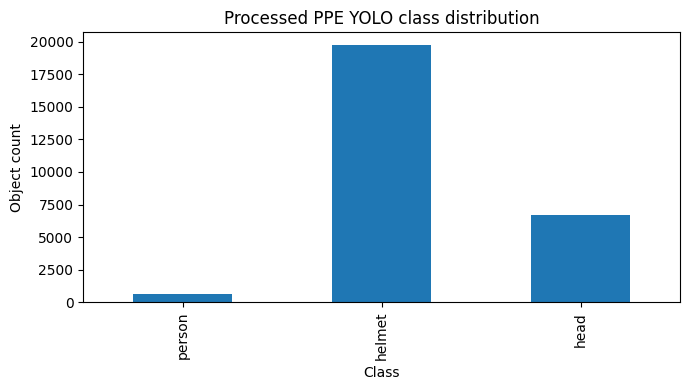

In [13]:
class_df = pd.read_csv(REPORT_DIR / 'processed_class_distribution.csv')
ax = class_df.plot(kind='bar', x='class_name', y='count', legend=False, figsize=(7, 4))
ax.set_title('Processed PPE YOLO class distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Object count')
plt.tight_layout()
plt.show()

## 12. Visualize processed labels on sample images

Cell này kiểm tra trực quan sau khi remap: box `person`, `helmet`, `head` đã khớp class chưa.

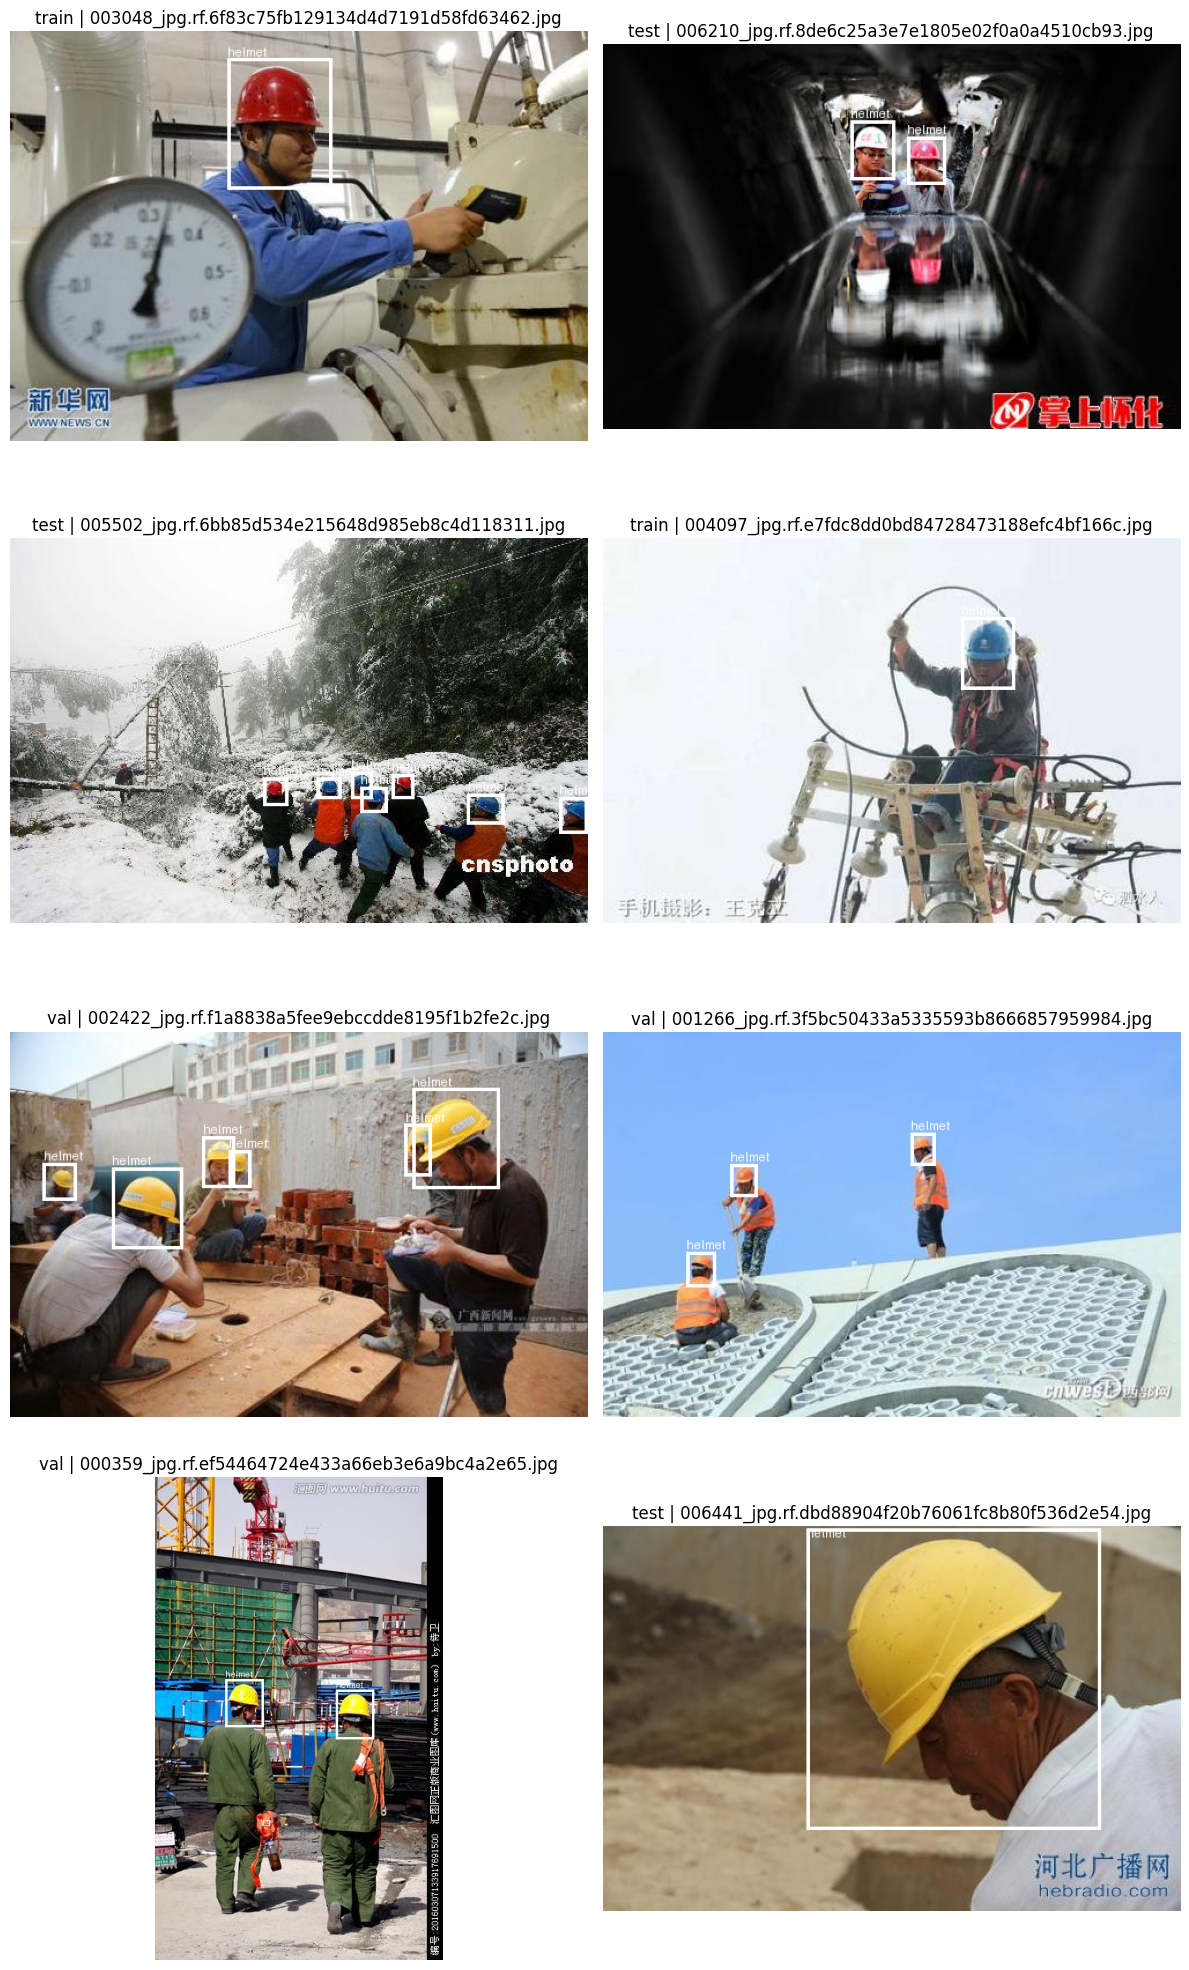

In [14]:
def load_yolo_labels(label_path: Path) -> List[Tuple[int, float, float, float, float]]:
    labels = []
    if not label_path.exists():
        return labels
    for line in label_path.read_text(encoding='utf-8').splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        x, y, w, h = map(float, parts[1:])
        labels.append((cls_id, x, y, w, h))
    return labels

def draw_yolo_boxes(image_path: Path, label_path: Path) -> Image.Image:
    img = Image.open(image_path).convert('RGB')
    draw = ImageDraw.Draw(img)
    W, H = img.size
    for cls_id, x, y, w, h in load_yolo_labels(label_path):
        x1 = (x - w / 2) * W
        y1 = (y - h / 2) * H
        x2 = (x + w / 2) * W
        y2 = (y + h / 2) * H
        draw.rectangle([x1, y1, x2, y2], width=3)
        draw.text((x1, max(0, y1 - 12)), TARGET_NAMES[cls_id])
    return img

sample_pool = []
for split in ['test', 'val', 'train']:
    images = sorted((PROCESSED_DIR / 'images' / split).glob('*'))
    images = [p for p in images if p.suffix.lower() in IMAGE_EXTENSIONS]
    sample_pool.extend([(split, p) for p in images])

random.seed(42)
show_samples = random.sample(sample_pool, min(8, len(sample_pool)))

if not show_samples:
    print('No samples to visualize.')
else:
    cols = 2
    rows = (len(show_samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    if rows == 1:
        axes = [axes] if cols == 1 else axes
    axes_flat = list(axes.flatten()) if hasattr(axes, 'flatten') else list(axes)

    for ax, (split, img_path) in zip(axes_flat, show_samples):
        label_path = PROCESSED_DIR / 'labels' / split / f'{img_path.stem}.txt'
        drawn = draw_yolo_boxes(img_path, label_path)
        ax.imshow(drawn)
        ax.set_title(f'{split} | {img_path.name}')
        ax.axis('off')

    for ax in axes_flat[len(show_samples):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

## 13. Run existing validation script if available

Dùng script của project nếu có. Nếu script nhận argument khác thì cell này sẽ báo và bạn có thể chạy `--help`.

In [15]:
VALIDATE_SCRIPT = PROJECT_ROOT / 'src' / 'data' / 'validate_yolo_dataset.py'
if VALIDATE_SCRIPT.exists():
    print('Validation script found:', VALIDATE_SCRIPT.relative_to(PROJECT_ROOT))
    !python src/data/validate_yolo_dataset.py --help
else:
    print('No validate_yolo_dataset.py found. Built-in validation above is enough for now.')

Validation script found: src/data/validate_yolo_dataset.py
usage: validate_yolo_dataset.py [-h] --dataset-dir DATASET_DIR [--verbose]

Validate YOLO dataset labels.

options:
  -h, --help            show this help message and exit
  --dataset-dir DATASET_DIR
                        Dataset root containing images/ and labels/.
  --verbose             Enable debug logging.


## 14. Next training plan

Sau khi notebook này pass, chạy lại notebook 01 và 02:

```text
01_yolo8s_ppe_baseline.ipynb
02_yolo11s_ppe_candidate.ipynb
```

Vì `data/processed/ppe_yolo/data.yaml` đã có ảnh nên 2 notebook đó sẽ ưu tiên dataset processed này.

Khuyến nghị config tiếp theo:

```text
EPOCHS = 10 trước
nếu ổn thì EPOCHS = 30
IMGSZ = 640
BATCH = 8 trên T4, nếu OOM thì BATCH = 4
SEED = 42
```

Tiêu chí quan trọng nhất sau khi train lại:

1. `person` recall
2. `head/no-helmet` recall
3. `helmet` recall
4. mAP50 / mAP50-95
5. clean FPS
6. qualitative prediction trên ảnh mẫu

In [16]:
print('Processed dataset ready at:', DATA_YAML_PATH.relative_to(PROJECT_ROOT))
print('Suggested next commands/notebooks:')
print('1) Open notebooks/01_yolo8s_ppe_baseline.ipynb and set EPOCHS = 10 or 30')
print('2) Open notebooks/02_yolo11s_ppe_candidate.ipynb and set EPOCHS = 10 or 30')
print('3) Run notebooks/04_model_selection_summary.ipynb again')

Processed dataset ready at: data/processed/ppe_yolo/data.yaml
Suggested next commands/notebooks:
1) Open notebooks/01_yolo8s_ppe_baseline.ipynb and set EPOCHS = 10 or 30
2) Open notebooks/02_yolo11s_ppe_candidate.ipynb and set EPOCHS = 10 or 30
3) Run notebooks/04_model_selection_summary.ipynb again


## 15. Robust sync processed dataset and reports back to Drive

Cell này dùng **absolute path + assertion** để chắc chắn `data/processed/ppe_yolo/data.yaml` thật sự được copy về Drive cho notebook 01/02.


In [17]:
# Robust final sync: copy processed dataset + config + reports back to Drive using absolute paths.
# This cell intentionally uses pathlib/shutil instead of relative shell cp, so it does not depend on %cd.

from pathlib import Path
import shutil
import json

IN_COLAB = Path('/content').exists() and 'COLAB_RELEASE_TAG' in os.environ

if IN_COLAB:
    LOCAL_PROJECT = Path('/content/factory-safety-ai-cctv')
    DRIVE_PROJECT = Path('/content/drive/MyDrive/factory-safety-ai-cctv')

    local_processed = LOCAL_PROJECT / 'data/processed/ppe_yolo'
    drive_processed = DRIVE_PROJECT / 'data/processed/ppe_yolo'

    local_config = LOCAL_PROJECT / 'src/configs/ppe_data.yaml'
    drive_config = DRIVE_PROJECT / 'src/configs/ppe_data.yaml'

    local_report = LOCAL_PROJECT / 'experiments/processed_dataset_setup'
    drive_report = DRIVE_PROJECT / 'experiments/processed_dataset_setup'

    required_local_paths = [
        local_processed / 'data.yaml',
        local_processed / 'images/train',
        local_processed / 'images/val',
        local_processed / 'images/test',
        local_processed / 'labels/train',
        local_processed / 'labels/val',
        local_processed / 'labels/test',
        local_config,
        local_report,
    ]

    print('Checking local artifacts before sync...')
    for path in required_local_paths:
        print(path, 'exists =', path.exists())
        assert path.exists(), f'Missing required local artifact before sync: {path}'

    print('\nSyncing processed dataset to Drive...')
    drive_processed.parent.mkdir(parents=True, exist_ok=True)
    shutil.rmtree(drive_processed, ignore_errors=True)
    shutil.copytree(local_processed, drive_processed)

    print('Syncing config to Drive...')
    drive_config.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(local_config, drive_config)

    print('Syncing reports to Drive...')
    drive_report.parent.mkdir(parents=True, exist_ok=True)
    shutil.rmtree(drive_report, ignore_errors=True)
    shutil.copytree(local_report, drive_report)

    def count_files(folder, suffixes=None):
        folder = Path(folder)
        if not folder.exists():
            return 0
        if suffixes is None:
            return len([p for p in folder.rglob('*') if p.is_file()])
        suffixes = {s.lower() for s in suffixes}
        return len([p for p in folder.rglob('*') if p.is_file() and p.suffix.lower() in suffixes])

    final_check = {
        'drive_data_yaml_exists': (drive_processed / 'data.yaml').exists(),
        'drive_config_exists': drive_config.exists(),
        'drive_train_images': count_files(drive_processed / 'images/train', {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}),
        'drive_val_images': count_files(drive_processed / 'images/val', {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}),
        'drive_test_images': count_files(drive_processed / 'images/test', {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}),
        'drive_train_labels': count_files(drive_processed / 'labels/train', {'.txt'}),
        'drive_val_labels': count_files(drive_processed / 'labels/val', {'.txt'}),
        'drive_test_labels': count_files(drive_processed / 'labels/test', {'.txt'}),
    }

    print('\nFinal Drive sync check:')
    print(json.dumps(final_check, indent=2))

    assert final_check['drive_data_yaml_exists'], f'Drive data.yaml missing after sync: {drive_processed / "data.yaml"}'
    assert final_check['drive_train_images'] > 0, 'Drive train split is empty after sync'
    assert final_check['drive_val_images'] > 0, 'Drive val split is empty after sync'
    assert final_check['drive_test_images'] > 0, 'Drive test split is empty after sync'

    print('\n✅ Sync complete and verified.')
    print('Drive processed dataset:', drive_processed)
else:
    print('Not in Colab. No Drive sync needed.')

In [1]:
# Final sanity check: local + Drive paths that notebook 01/02 will need.

from pathlib import Path
import json

LOCAL_PROJECT = Path('/content/factory-safety-ai-cctv')
DRIVE_PROJECT = Path('/content/drive/MyDrive/factory-safety-ai-cctv')

paths = {
    'local_data_yaml': LOCAL_PROJECT / 'data/processed/ppe_yolo/data.yaml',
    'drive_data_yaml': DRIVE_PROJECT / 'data/processed/ppe_yolo/data.yaml',
    'local_project_config': LOCAL_PROJECT / 'src/configs/ppe_data.yaml',
    'drive_project_config': DRIVE_PROJECT / 'src/configs/ppe_data.yaml',
}

for name, path in paths.items():
    print(f'{name}: {path}')
    print('exists:', path.exists())
    if path.exists() and path.name.endswith(('.yaml', '.yml')):
        print(path.read_text(encoding='utf-8')[:500])
    print('-' * 80)

def count_images(root, split):
    img_dir = root / f'data/processed/ppe_yolo/images/{split}'
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    return len([p for p in img_dir.glob('*') if p.suffix.lower() in exts]) if img_dir.exists() else 0

summary = {}
for base_name, base in [('local', LOCAL_PROJECT), ('drive', DRIVE_PROJECT)]:
    summary[base_name] = {
        split: count_images(base, split)
        for split in ['train', 'val', 'test']
    }

print('Image count summary:')
print(json.dumps(summary, indent=2))

assert paths['local_data_yaml'].exists(), 'Local processed data.yaml is missing.'
assert paths['drive_data_yaml'].exists(), 'Drive processed data.yaml is missing.'
assert summary['local']['val'] > 0, 'Local val split is empty.'
assert summary['drive']['val'] > 0, 'Drive val split is empty.'

print('✅ Notebook 05 output is ready for notebook 01/02 force_processed.')